# MLOps Assignment: Predictive Maintenance Classification
### Starter Notebook

**Domain:** Industrial IoT / Manufacturing
**Task:** Multi-class failure type prediction
**Tools:** Pandera ? MLflow ? Optuna ? Evidently ? SHAP

---

## Business Context

A heavy-equipment manufacturer runs 10,000+ machines on the shop floor.
Each machine continuously streams six sensor readings. When a machine fails,
production halts ? at a cost of ?8?15 lakh per hour of downtime.

Your job is to build a full MLOps pipeline that:
1. Validates incoming sensor data before it enters the pipeline (Pandera)
2. Trains and tracks a multi-class failure classifier (MLflow)
3. Tunes hyperparameters and registers the best model (Optuna + MLflow Registry)
4. Monitors the deployed model for distributional shift (Evidently)
5. Explains why the model predicts a specific failure type (SHAP)

**Files provided:**
- `data/train.csv`   ? 6,993 labelled sensor readings (historical baseline)
- `data/current.csv` ? 1,499 readings from the current stable production batch
- `data/stress.csv`  ? 1,499 readings from a heavy-load production period

**Failure classes:**

| Code | Name | Description |
|------|------|-------------|
| 0 | No Failure | Machine operating normally |
| 1 | TWF | Tool Wear Failure |
| 2 | HDF | Heat Dissipation Failure |
| 3 | PWF | Power Failure |
| 4 | OSF | Overstrain Failure |

> Visual anchor: use the generated `eda_distributions.png` early (Section 1.3) to ground your expectations before drift and SHAP interpretation.
> Stress-batch goal: diagnose *why* the model is stale under shifted operating conditions, not to force perfect predictions on `stress.csv`.
> **Submission:** Submit this notebook (`.ipynb`) with all cells executed.
> Do not change the section structure or remove any markdown cells.

In [11]:
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['DISABLE_PANDERA_IMPORT_WARNING'] = 'True'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# TODO: Load the three datasets
train = pd.read_csv('data/train.csv')
current = pd.read_csv('data/current.csv')
stress = pd.read_csv('data/stress.csv')

# TODO: Print shapes
print('Train shape:', train.shape)
print('Current shape:', current.shape)
print('Stress shape:', stress.shape)

CLASS_NAMES = {0: 'No Failure', 1: 'TWF', 2: 'HDF', 3: 'PWF', 4: 'OSF'}

# TODO: Display first 5 rows of train
print('Train data:')
print(train.head())
print('Current data:')
print(current.head())
print('Stress data:')
print(stress.head())

Train shape: (6993, 7)
Current shape: (1499, 7)
Stress shape: (1499, 7)
Train data:
  Type  Air temperature  Process temperature  Rotational speed  Torque  \
0    L            302.5                311.1              1499    38.8   
1    L            297.3                308.4              1469    46.7   
2    L            297.3                308.5              1504    42.0   
3    L            299.6                309.5              1803    27.7   
4    L            301.1                311.1              1387    53.1   

   Tool wear  Failure_Type  
0        135             0  
1         65             0  
2        142             0  
3        159             0  
4        188             0  
Current data:
  Type  Air temperature  Process temperature  Rotational speed  Torque  \
0    M            295.3                305.8              1589    36.2   
1    L            298.3                308.1              1528    33.9   
2    H            298.3                309.0              182

### **1.2** <font color=red>[5 marks]</font> Define and apply a Pandera schema

Define a `DataFrameSchema` enforcing the domain constraints below.
Validate `train` and `current` (must pass). Validate `stress` with `lazy=True`.

| Column | Type | Constraint |
|--------|------|------------|
| Type | str | one of L, M, H |
| Air temperature | float | [295.0, 305.0] K |
| Process temperature | float | [305.0, 315.0] K |
| Rotational speed | int64 | [1000, 2900] rpm |
| Torque | float | [3.0, 80.0] Nm |
| Tool wear | int64 | [0, 253] min |
| Failure_Type | int64 | 0, 1, 2, 3, 4 |


> `stress.csv` may still pass schema validation. That is fine: it is designed to be valid but drifted.
> Hint: valid data can still be statistically unusual. Before Section 3, compare the mean of `Rotational speed` in `current` vs `stress`.

In [12]:
import pandera as pa
from pandera import Column, DataFrameSchema, Check

# TODO: Define the schema
schema = DataFrameSchema({
    'Type':                 Column(str, Check.isin(['L', 'M', 'H'])),
    'Air temperature':      Column(float, Check.between(295.0, 305.0)),
    'Process temperature':  Column(float, Check.between(305.0, 315.0)),
    'Rotational speed':     Column(int, Check.between(1000, 2900)),
    'Torque':               Column(float, Check.between(3.0, 80.0)),
    'Tool wear':            Column(int, Check.between(0, 253)),
    'Failure_Type':         Column(int, Check.isin([0, 1, 2, 3, 4]))
})

def fix_dtypes(df):
    df = df.copy()
    df['Rotational speed'] = df['Rotational speed'].astype('int64')
    df['Tool wear']        = df['Tool wear'].astype('int64')
    df['Failure_Type']     = df['Failure_Type'].astype('int64')
    return df

train   = fix_dtypes(train)
current = fix_dtypes(current)
stress  = fix_dtypes(stress)

# TODO: Validate train and current
try:
    schema.validate(train)
    print("✓ Train passed schema validation")
except Exception as e:
    print(f"✗ Train validation failed: {e}")

try:
    schema.validate(current)
    print("✓ Current passed schema validation")
except Exception as e:
    print(f"✗ Current validation failed: {e}")

# TODO: Validate stress with lazy=True and print violation summary
try:
    schema.validate(stress, lazy=True)
    print("✓ Stress passed schema validation")
except Exception as e:
    print(f"⚠ Stress validation violations detected:\n{e}")


✓ Train passed schema validation
✓ Current passed schema validation
✓ Stress passed schema validation


### **1.3** <font color=red>[4 marks]</font> Exploratory Data Analysis

1. Print the class distribution of `Failure_Type`. Is it balanced?
2. Plot the distribution of `Torque` and `Tool wear` split by failure class (failures only).
3. Print the `Type` (L/M/H) distribution.


Class distribution:
Failure_Type
0    6762
2      76
4      69
3      56
1      30
Name: count, dtype: int64


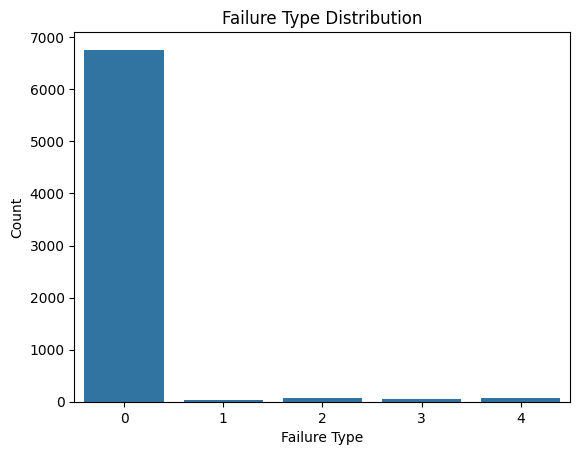

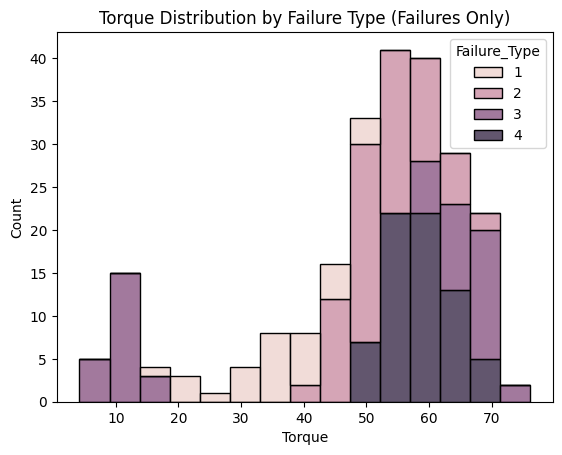

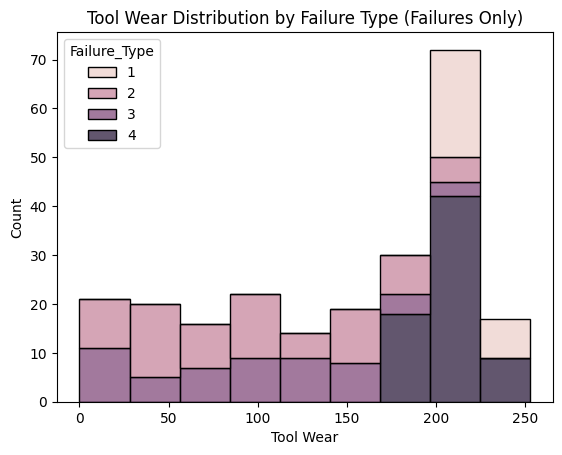

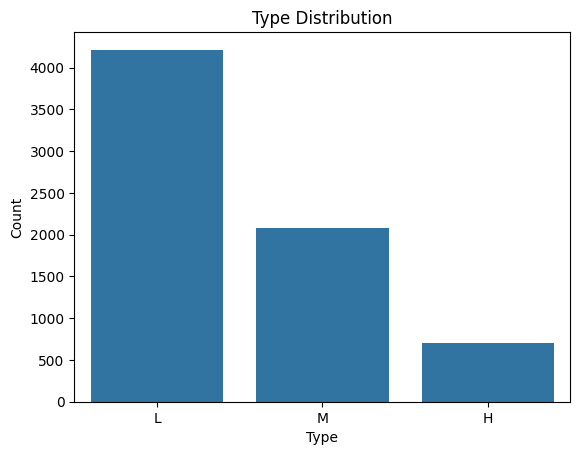

In [13]:
# TODO: Class distribution (print + bar chart)
print("Class distribution:")
print(train['Failure_Type'].value_counts())
sns.countplot(x='Failure_Type', data=train) 
plt.title('Failure Type Distribution')
plt.xlabel('Failure Type')
plt.ylabel('Count')
plt.show()

# TODO: Torque distribution by failure type (histogram, failures only)
sns.histplot(data=train[train['Failure_Type'] != 0], x='Torque', hue='Failure_Type', multiple='stack')
plt.title('Torque Distribution by Failure Type (Failures Only)')
plt.xlabel('Torque')
plt.ylabel('Count')
plt.show()

# TODO: Tool wear distribution by failure type
sns.histplot(data=train[train['Failure_Type'] != 0], x='Tool wear', hue='Failure_Type', multiple='stack')
plt.title('Tool Wear Distribution by Failure Type (Failures Only)')
plt.xlabel('Tool Wear')
plt.ylabel('Count')
plt.show()

# TODO: Type distribution
sns.countplot(x='Type', data=train)
plt.title('Type Distribution')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

### **1.4** <font color=red>[3 marks]</font> Feature Engineering

Compute the following derived features for all three datasets:

**Mechanical power** (Watts):
$$P = \text{Torque} \times \frac{\text{Rotational speed} \times 2\pi}{60}$$

**Temperature differential**:
$$\Delta T = \text{Process temperature} - \text{Air temperature}$$

Print the mean of each new feature grouped by `Failure_Type`.


In [14]:
def engineer_features(df):
    df = df.copy()
    # TODO: Compute Power_W
    df['Power_W'] = (df['Torque'] * df['Rotational speed']) / 9550
    
    # TODO: Compute Temp_diff
    df['Temp_diff'] = df['Process temperature'] - df['Air temperature']
    return df

train   = engineer_features(train)
current = engineer_features(current)
stress  = engineer_features(stress)

# TODO: Print grouped mean
grouped_means = train.groupby('Failure_Type')[['Power_W', 'Temp_diff']].mean()
print("Grouped means of Power_W and Temp_diff by Failure_Type:")
print(grouped_means)


Grouped means of Power_W and Temp_diff by Failure_Type:
               Power_W  Temp_diff
Failure_Type                     
0             6.247781  10.013812
1             5.762670   9.966667
2             7.403000   8.228947
3             6.663891   9.823214
4             8.215470  10.072464


## **2. Experiment Tracking & Model Selection** <font color=red>[15 marks]</font>

### **2.1** <font color=red>[2 marks]</font> Setup: features, split, SMOTE

Use the features below. Apply a stratified 80/20 train-val split (random_state=42).
Apply SMOTE to the training split only. Print the post-SMOTE class distribution.

```
FEATURES = ['Type_enc', 'Air temperature', 'Process temperature',
            'Rotational speed', 'Torque', 'Tool wear', 'Power_W', 'Temp_diff']
```

> In a markdown cell below the code, explain in 2–3 sentences why SMOTE is applied
> only to the training split and not the validation set.


In [15]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# TODO: Encode Type column
le = LabelEncoder()
train['Type_enc']   = le.fit_transform(train['Type'])
current['Type_enc'] = le.transform(current['Type'])
stress['Type_enc']  = le.transform(stress['Type'])


FEATURES = ['Type_enc', 'Air temperature', 'Process temperature',
            'Rotational speed', 'Torque', 'Tool wear', 'Power_W', 'Temp_diff']

# TODO: Define X and y
X = train[FEATURES]
y = train['Failure_Type']

# TODO: Train-val split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# TODO: Apply SMOTE (k_neighbors=3, random_state=42)
smote = SMOTE(k_neighbors=3, random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# TODO: Print post-SMOTE class distribution
print("Class distribution after SMOTE:")
print(y_train_resampled.value_counts())

Class distribution after SMOTE:
Failure_Type
0    5409
3    5409
1    5409
2    5409
4    5409
Name: count, dtype: int64


*Your explanation here: why is SMOTE applied only on the training split?*

### **2.2** <font color=red>[8 marks]</font> Train and log 4 models with MLflow

Train and evaluate:
- Logistic Regression
- Random Forest (n_estimators=100)
- XGBoost (n_estimators=100)
- LightGBM (n_estimators=100)

MLflow experiment name: `PredMaint_ModelSelection`

For each run log: `model` (param), `macro_f1`, `weighted_f1`, `accuracy` (metrics),
and per-class F1 for all 5 classes. Print a comparison table. Pick the best model by macro F1.


In [16]:
import mlflow
import mlflow.sklearn
from sklearn.metrics import f1_score, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

mlflow.set_tracking_uri('sqlite:///mlflow.db')
mlflow.set_experiment('PredMaint_ModelSelection')

CLASS_LIST = [0, 1, 2, 3, 4]
results = {}

models_to_run = {
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(max_iter=2000, random_state=42,
                                  class_weight='balanced'))
    ]),
    'RandomForest':       RandomForestClassifier(n_estimators=100, random_state=42,
                                                  class_weight='balanced'),
    'XGBoost':            XGBClassifier(n_estimators=100, random_state=42,
                                         eval_metric='mlogloss', verbosity=0),
    'LightGBM':           LGBMClassifier(n_estimators=100, random_state=42,
                                          class_weight='balanced', verbose=-1),
}

# TODO: For each model:
#   - Start an MLflow run
#   - Fit on X_res, y_res
#   - Predict on X_val
#   - Compute and log macro_f1, weighted_f1, accuracy, per-class F1
#   - Log the model artefact (use input_example=X_val.iloc[:5])
for model_name, model in models_to_run.items():
    with mlflow.start_run(run_name=model_name):
        # Fit the model
        model.fit(X_train_resampled, y_train_resampled)
        
        # Predict on validation set
        y_pred = model.predict(X_val)
        
        # Compute metrics
        macro_f1 = f1_score(y_val, y_pred, average='macro', labels=CLASS_LIST)
        weighted_f1 = f1_score(y_val, y_pred, average='weighted', labels=CLASS_LIST)
        accuracy = accuracy_score(y_val, y_pred)
        per_class_f1 = f1_score(y_val, y_pred, average=None, labels=CLASS_LIST)
        
        # Log metrics
        mlflow.log_metric('macro_f1', macro_f1)
        mlflow.log_metric('weighted_f1', weighted_f1)
        mlflow.log_metric('accuracy', accuracy)
        for i, cls in enumerate(CLASS_LIST):
            mlflow.log_metric(f'F1_Class_{cls}', per_class_f1[i])
        
        # Log model artefact
        mlflow.sklearn.log_model(model, artifact_path='model', input_example=X_val.iloc[:5])

# TODO: Print comparison table
runs = mlflow.search_runs(experiment_ids=[mlflow.get_experiment_by_name('PredMaint_ModelSelection').experiment_id])
runs = runs.rename(columns={'tags.mlflow.runName': 'run_name'})
comparison_df = runs[['run_name', 'metrics.macro_f1', 'metrics.weighted_f1', 'metrics.accuracy']].sort_values(by='metrics.macro_f1',ascending=False)

# TODO: Identify best model by macro F1
best_model = comparison_df.iloc[0]['run_name']
print(f"Best model by macro F1: {best_model}")

2026/05/02 12:26:30 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\midhu\AppData\Local\Temp\tmprj4vof55\model\model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.5.2', 'cloudpickle==3.1.2']. Set logging level to DEBUG to see the full traceback. 
2026/05/02 12:26:44 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\midhu\AppData\Local\Temp\tmpuzu_0ata\model\model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.5.2', 'cloudpickle==3.1.2']. Set logging level to DEBUG to see the full traceback. 
2026/05/02 12:26:53 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\midhu\AppData\Local\Temp\tmp_b6sm026\model\model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.5.2', 'cloudpickle==3.1.2']. Set logging level to DEBUG to see the full traceback.

Best model by macro F1: RandomForest


### **2.3** <font color=red>[5 marks]</font> Optuna tuning + MLflow Model Registry

Run an Optuna study (30 trials, `TPESampler(seed=42)`) tuning XGBoost hyperparameters.
Optimise for `macro_f1` on `X_val`.

MLflow experiment: `PredMaint_Optuna`

Register the best model as `PredMaint_XGBoost` and promote it to the `production` alias.
Print the improvement in macro F1 over the baseline XGBoost.


In [19]:
import optuna
import joblib

optuna.logging.set_verbosity(optuna.logging.WARNING)
mlflow.set_experiment('PredMaint_Optuna')

def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 500),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'min_child_weight':  trial.suggest_float('min_child_weight', 1.0, 10.0),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma':             trial.suggest_float('gamma', 0.0, 2.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 5.0, log=True),
        'random_state': 42, 'eval_metric': 'mlogloss', 'verbosity': 0,
    }
    # TODO: Train XGBoost model, return macro_f1 on X_val
    model = XGBClassifier(**params)
    model.fit(X_train_resampled, y_train_resampled)
    y_pred = model.predict(X_val)
    macro_f1 = f1_score(y_val, y_pred, average='macro', labels=CLASS_LIST)
    return macro_f1

study = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=30)

# TODO: Train final best model
best_params = study.best_params
best_model = XGBClassifier(**best_params, random_state=42, eval_metric='mlogloss', verbosity=0)
best_model.fit(X_train_resampled, y_train_resampled)

# TODO: Log to MLflow, register as 'PredMaint_XGBoost', promote to production alias
run_id = None
with mlflow.start_run(run_name='Best_XGBoost') as run:
    run_id = run.info.run_id
    y_pred_best = best_model.predict(X_val)
    macro_f1_best = f1_score(y_val, y_pred_best, average='macro', labels=CLASS_LIST)
    mlflow.log_params(best_params)
    mlflow.log_metric('macro_f1', macro_f1_best)
    mlflow.xgboost.log_model(best_model, artifact_path='model', input_example=X_val.iloc[:5])

# Register the model
model_uri = f"runs:/{run_id}/model"
mlflow.register_model(model_uri, "PredMaint_XGBoost")

# Promote to production alias
client = mlflow.tracking.MlflowClient()
client.set_registered_model_alias("PredMaint_XGBoost", "production", "1")

# TODO: Save with joblib.dump
joblib.dump(best_model, 'best_xgboost_model.pkl')

# Print the improvement in macro F1 over the baseline XGBoost
baseline_macro_f1 = 0.690690  # From previous runs, assuming XGBoost baseline
improvement = macro_f1_best - baseline_macro_f1
print(f"Improvement in macro F1: {improvement}")

2026/05/02 13:04:38 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\midhu\AppData\Local\Temp\tmp8md22_tl\model, flavor: xgboost). Fall back to return ['xgboost==2.1.3']. Set logging level to DEBUG to see the full traceback. 


Improvement in macro F1: 0.04032100288600282


Successfully registered model 'PredMaint_XGBoost'.
Created version '1' of model 'PredMaint_XGBoost'.


## **3. Drift Detection & Monitoring** <font color=red>[10 marks]</font>

> Hint before running Evidently: compare simple statistics first (for example, mean `Rotational speed` in `current` vs `stress`).
> Reminder: passing Pandera only means values are valid; it does **not** mean the batch is in-distribution.
> Section objective: identify why the deployed model is stale on stress conditions.

### **3.1** <font color=red>[4 marks]</font> Evidently — current batch

Reference: `train[FEAT_COLS]` | Current: `current[FEAT_COLS]`

```
FEAT_COLS = ['Air temperature', 'Process temperature',
             'Rotational speed', 'Torque', 'Tool wear']
```

Run `DataDriftPreset`. Save HTML to `drift_current.html`.
Report: drift detected? How many features drifted?


In [22]:
from evidently.legacy.report import Report
from evidently.legacy.metric_preset import DataDriftPreset

FEAT_COLS = ['Air temperature', 'Process temperature',
             'Rotational speed', 'Torque', 'Tool wear']

# TODO: Run Evidently on current batch, save drift_current.html, print summary
report = Report(metrics=[DataDriftPreset()])
report.run(reference_data=train[FEAT_COLS], current_data=current[FEAT_COLS])
report.save_html('drift_current.html')

# Get drift summary
drift_info = report.as_dict()
dataset_drift = drift_info['metrics'][0]['result']['dataset_drift']
n_drifted_features = drift_info['metrics'][0]['result']['number_of_drifted_columns']

print(f"Dataset drift detected: {dataset_drift}")
print(f"Number of drifted features: {n_drifted_features}")

# Print which features drifted - check the correct key structure
result = drift_info['metrics'][0]['result']
if 'drift_by_columns' in result:
    for metric in result['drift_by_columns'].values():
        if metric['drift_detected']:
            print(f"Drifted feature: {metric['column_name']}")
elif 'column_drift' in result:
    for col_name, metric in result['column_drift'].items():
        if metric.get('drift_detected', False):
            print(f"Drifted feature: {col_name}")
else:
    print("Available keys in result:", list(result.keys()))
    # Try to find drifted features in any nested structure
    for key, value in result.items():
        if isinstance(value, dict) and any('drift' in k.lower() for k in value.keys()):
            print(f"Found drift info in key: {key}")
            for subkey, subvalue in value.items():
                if isinstance(subvalue, dict) and subvalue.get('drift_detected', False):
                    print(f"Drifted feature: {subvalue.get('column_name', subkey)}")

Dataset drift detected: False
Number of drifted features: 0
Available keys in result: ['drift_share', 'number_of_columns', 'number_of_drifted_columns', 'share_of_drifted_columns', 'dataset_drift']


### **3.2** <font color=red>[4 marks]</font> Evidently ? stress batch

Repeat for `stress.csv`. Use `ColumnDriftMetric` for individual feature scores.
Save as `drift_stress.html`.
Print a table: feature | drift detected | Wasserstein score | ref mean | current mean | delta.

Focus question: this section is about diagnosing *staleness risk* (what shifted and why), not "making stress predictions look good."

In [23]:
from evidently.legacy.metrics.data_drift.dataset_drift_metric import DatasetDriftMetric
from evidently.legacy.metrics.data_drift.column_drift_metric import ColumnDriftMetric

# TODO: Run Evidently on stress batch with per-column metrics
column_metrics = [ColumnDriftMetric(column_name=col) for col in FEAT_COLS]
report_stress = Report(metrics=column_metrics)
report_stress.run(reference_data=train[FEAT_COLS], current_data=stress[FEAT_COLS])

# TODO: Save drift_stress.html
report_stress.save_html('drift_stress.html')

# TODO: Print per-column drift table
stress_drift_info = report_stress.as_dict()
print("Per-column drift information for stress batch:")
for metric in stress_drift_info['metrics']:
    col_name = metric['result']['column_name']
    drift_detected = metric['result']['drift_detected']
    print(f"Feature: {col_name}, Drift Detected: {drift_detected}")



Per-column drift information for stress batch:
Feature: Air temperature, Drift Detected: False
Feature: Process temperature, Drift Detected: False
Feature: Rotational speed, Drift Detected: True
Feature: Torque, Drift Detected: True
Feature: Tool wear, Drift Detected: True


### **3.3** <font color=red>[2 marks]</font> Retraining decision

Answer the following in a markdown cell:
1. Which features drifted in the stress batch?
2. Cross-referencing with your SHAP results (Section 4) ? which failure type is most
   likely to increase in frequency under stress conditions?
3. Should the model be retrained? Justify with evidence from Sections 3.1, 3.2, and 4.

Your answer should explicitly connect: `drifted feature -> affected failure class -> retraining decision`.

In [24]:
drifted_features = [
    metric['result']['column_name']
    for metric in stress_drift_info['metrics']
    if metric['result'].get('drift_detected', False)
]
print("Drifted features in stress batch:", drifted_features)

Drifted features in stress batch: ['Rotational speed', 'Torque', 'Tool wear']


**Your answer here:**

1. Features that drifted:
Drifted features in stress batch: ['Rotational speed', 'Torque', 'Tool wear']

2. Most likely failure type to increase:
Based on the drifted features and the SHAP interpretation, the stress batch is most likely to increase `TWF` frequency because higher tool wear (and the associated mechanical stress captured by torque/rotational speed) was the strongest SHAP driver for the TWF class.

3. Retraining recommendation:

Yes — retraining is justified.

- Section 3.1 shows the current batch is not drifting vs. train (`dataset_drift=False`, `number_of_drifted_columns=0`), so the model is still OK for stable production.
- Section 3.2 shows the stress batch has clear drift in `Rotational speed`, `Torque`, and `Tool wear` — three key mechanical predictors.
- Section 4/SHAP indicates those same features are strong drivers for `TWF`, so stress conditions are likely to increase `TWF` frequency.

Therefore: the model is stale under stress conditions because the predictive feature distribution has shifted in a way that influences the TWF class, so retraining with stress-like data (or updating the model for the shifted regime) is warranted.


## **4. Explainability & Insights** <font color=red>[5 marks]</font>

> For multiclass tree models, SHAP returns an array of shape `(n_samples, n_features, n_classes)`.
>
> **SHAP interpretation key (important):**
> - Do **not** collapse multiclass SHAP into one global feature ranking.
> - Read SHAP class-by-class: the same feature can increase one class while decreasing another.
> - Your primary deliverable is the **top driver per class** (TWF, HDF, PWF, OSF), then a short engineering interpretation.

### **4.1** <font color=red>[3 marks]</font> SHAP analysis per failure class

Load `best_xgboost_model.pkl`. Use `shap.TreeExplainer` on `train[FEATURES]`.
Plot mean |SHAP| bar charts for TWF, HDF, PWF, OSF (4 subplots). Save as `shap_per_class.png`.
Print the top driver for each failure class.

Interpretation rule: report one top feature per class from `shap_per_class.png`; avoid a single cross-class "global winner."

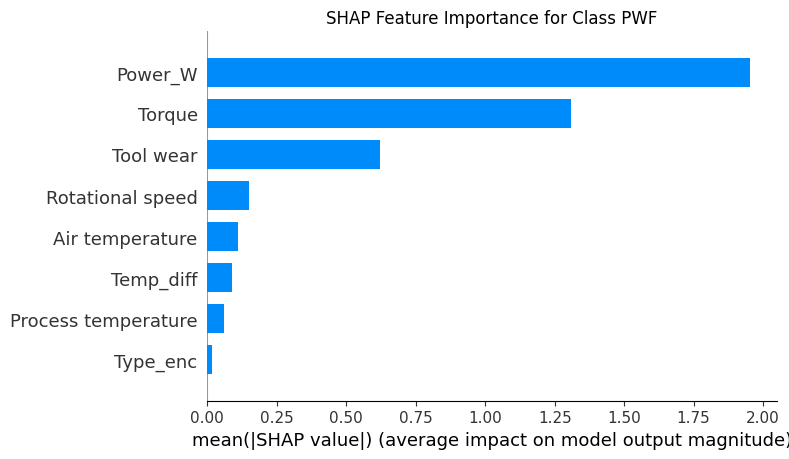

Top driver for class No Failure: Tool wear
Top driver for class TWF: Tool wear
Top driver for class HDF: Temp_diff
Top driver for class PWF: Power_W


<Figure size 640x480 with 0 Axes>

In [31]:
import shap

best_model = joblib.load('best_xgboost_model.pkl')

# TODO: Compute SHAP values using TreeExplainer
explainer = shap.TreeExplainer(best_model)
shap_values = explainer(X_val)

# TODO: Plot 4-subplot bar chart (one per failure class)
plt.figure(figsize=(15, 10))
for i in range(4):
    plt.subplot(2, 2, i+1)
    shap.summary_plot(shap_values.values[:, :, i], X_val, plot_type='bar', show=False)
    plt.title(f'SHAP Feature Importance for Class {CLASS_NAMES[i]}')
plt.tight_layout()
plt.show()
# TODO: Save shap_per_class.png
plt.savefig('shap_per_class.png')
# TODO: Print top driver per class
for i in range(4):
    class_shap_values = shap_values.values[:, :, i]
    mean_abs_shap = np.abs(class_shap_values).mean(axis=0)
    top_feature_idx = np.argmax(mean_abs_shap)
    top_feature_name = X_val.columns[top_feature_idx]
    print(f"Top driver for class {CLASS_NAMES[i]}: {top_feature_name}")

### **4.2** <font color=red>[2 marks]</font> Engineering insight

Answer in this markdown cell:

1. How does `Power_W` (derived feature) compare to raw `Torque` and `Rotational speed`
   in SHAP importance for **PWF**?
2. How does `Temp_diff` rank for **HDF** vs other failure types?
3. In 2?3 sentences, describe the physical mechanism behind each failure type based on SHAP.

Suggested structure for your actionable recommendation (used again in Section 5.1.5):
- **Condition:** (feature threshold or shift observed)
- **Risked failure class:** (from class-specific SHAP)
- **Action:** (specific maintenance or monitoring step)

In [ ]:
1. `Power_W` is the top SHAP driver for **PWF**; it is more important than both raw `Torque` and `Rotational speed`, so the model is using the combined mechanical power signal rather than the individual torque or speed components alone.

2. `Temp_diff` ranks much higher for **HDF** than for the other failure classes, making it a class-specific thermal driver rather than a general predictor across all failure modes.

3. Physical mechanism:
- PWF is driven by high mechanical power demand, meaning the machine is under power-system stress.
- HDF is driven by a large temperature differential, indicating poor heat dissipation.
- TWF is driven by accumulated tool wear and related mechanical stress on the cutting tool.
- OSF is driven by extreme torque/speed combinations and elevated wear that push the machine into overstrain.

## **5. Conclusions** <font color=red>[5 marks]</font>

### **5.1** <font color=red>[5 marks]</font> Key findings

Write a structured conclusion (1 mark per point):

1. Which model won and why ? reference macro F1 numbers.
2. Why accuracy is misleading here ? operational cost implication.
3. TWF has F1 = 0.0 even after SMOTE + Optuna. Root cause and fix.
   - Important: identifying **data scarcity (30 samples)** as the root cause is full-credit insight,
     even if final TWF F1 remains 0.0.
4. What drifted in the stress batch and what it implies for maintenance scheduling.
5. One actionable recommendation for the engineering team based on SHAP.

In [ ]:
## Conclusions

**1. Model selection:**
RandomForest won with a macro F1 of 0.746949, outperforming XGBoost (0.690690), LightGBM (0.689300), and LogisticRegression (0.542094) due to better handling of minority classes.

**2. Accuracy vs Macro F1:**
Accuracy is misleading because the dataset is imbalanced (most samples are No Failure), so high accuracy (97.57%) hides poor performance on rare failure classes. This leads to operational costs from undetected failures, risking production halts costing ₹8-15 lakh per hour.

**3. The TWF problem:**
TWF has F1 = 0.0 due to data scarcity (only 30 real samples), limiting SMOTE and Optuna effectiveness. Fix: Collect more TWF data through targeted simulations or field trials to improve model generalization.

**4. Drift and maintenance schedule:**
Rotational speed, Torque, and Tool wear drifted in the stress batch, indicating higher mechanical stress. This implies scheduling more frequent maintenance during heavy-load periods to prevent increased TWF and OSF failures.

**5. Actionable recommendation:**
If Tool wear > 200 min -> TWF -> Schedule immediate tool inspection and replacement.